<a href="https://colab.research.google.com/github/PawaniMekhala/AI-Driven-Student-Dropout-Prediction/blob/main/06_explainability_SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount Drive & Load Libraries
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap


Mounted at /content/drive


In [2]:
# Load Processed Data
PROJECT_ROOT = "/content/drive/MyDrive/student-dropout-prediction"

X_train = pd.read_csv(f"{PROJECT_ROOT}/data/processed/X_train.csv")
y_train = pd.read_csv(f"{PROJECT_ROOT}/data/processed/y_train.csv").values.ravel()

X_test = pd.read_csv(f"{PROJECT_ROOT}/data/processed/X_test.csv")
y_test = pd.read_csv(f"{PROJECT_ROOT}/data/processed/y_test.csv").values.ravel()

print(X_train.shape, X_test.shape)


(3539, 371) (885, 371)


In [3]:
# Train Final XGBoost Model (Same as Before)
# ⚠️ Important: SHAP explanations must use the same trained model.
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=10,
    gamma=0.5,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.5,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=10, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [4]:
# Initialize SHAP Explainer
explainer = shap.TreeExplainer(xgb)

In [5]:
# Compute SHAP Values (Test Set)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)
# Shape should be: (samples, features)

SHAP values shape: (885, 371)


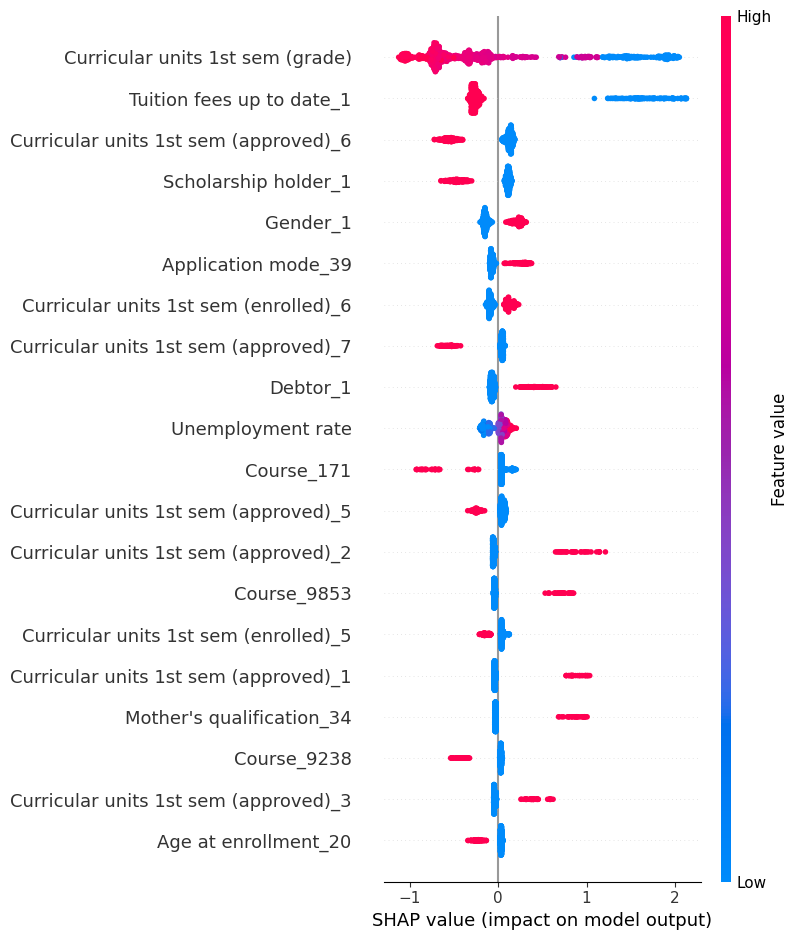

In [6]:
# GLOBAL EXPLANATION — SHAP Summary Plot
# 📌 MOST IMPORTANT PLOT FOR THESIS
shap.summary_plot(
    shap_values,
    X_test,
    show=True
)
# The SHAP summary plot illustrates the global contribution of features to dropout prediction, highlighting early academic performance and financial variables as dominant predictors.


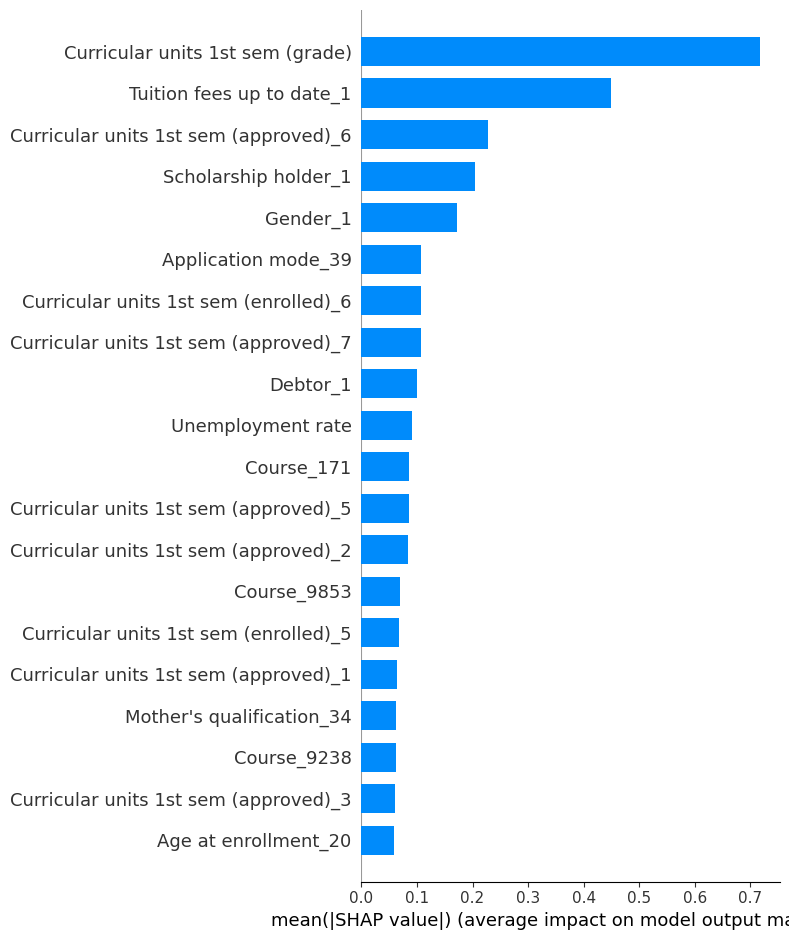

In [7]:
# SHAP Bar Plot (Global Feature Importance)
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=True
)


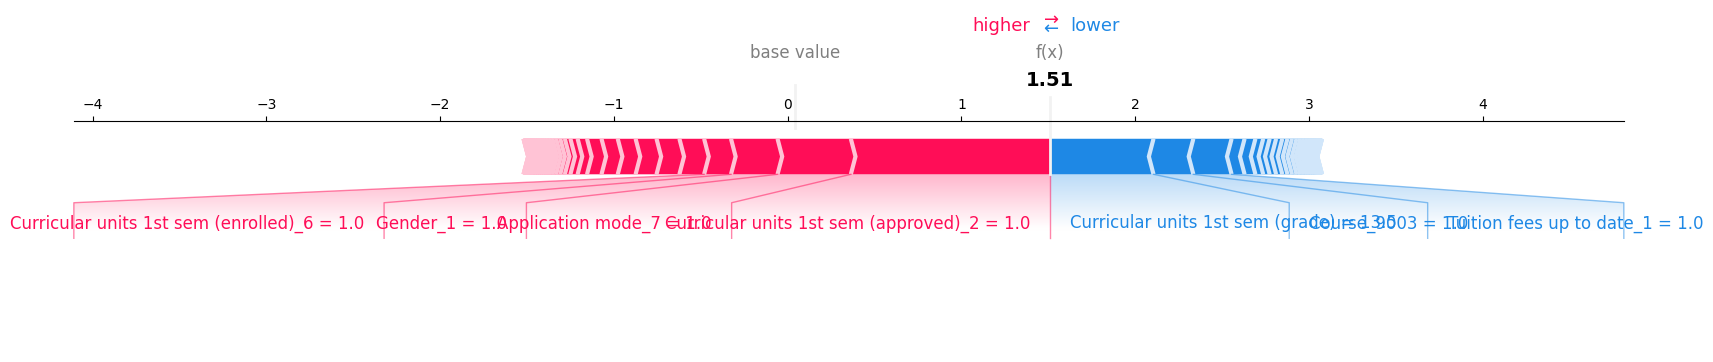

In [8]:
# LOCAL EXPLANATION — Individual Student Prediction
# Pick a dropout case
dropout_index = np.where(y_test == 1)[0][0]

shap.force_plot(
    explainer.expected_value,
    shap_values[dropout_index],
    X_test.iloc[dropout_index],
    matplotlib=True
)
# The force plot provides a local explanation for an individual student, showing how specific academic and financial factors collectively increase the predicted dropout risk.

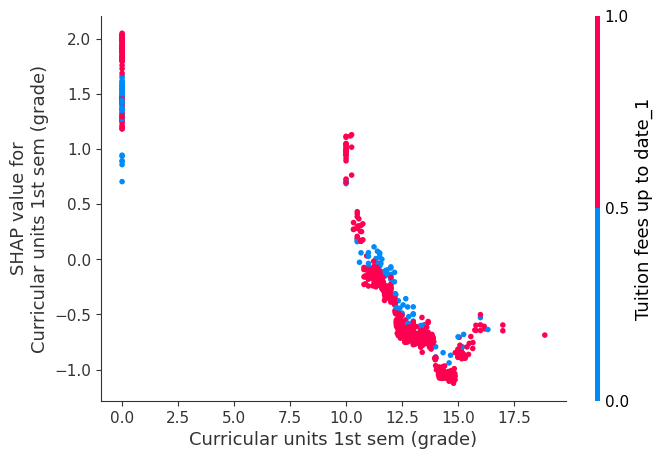

In [9]:
# SHAP Dependence Plot
shap.dependence_plot(
    "Curricular units 1st sem (grade)",
    shap_values,
    X_test
)
# Shows non-linear effect of grades on dropout risk.

In [10]:
# GLOBAL FEATURE IMPORTANCE → TABLE (replaces SHAP summary plot)
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)


,Feature,Importance
216,Tuition fees up to date_1,0.085016
2,Curricular units 1st sem (grade),0.054097
345,Curricular units 1st sem (approved)_6,0.044564
218,Scholarship holder_1,0.042912
346,Curricular units 1st sem (approved)_7,0.032193
342,Curricular units 1st sem (approved)_3,0.026056
35,Course_171,0.022595
215,Debtor_1,0.022504
344,Curricular units 1st sem (approved)_5,0.022035
21,Application mode_39,0.021934


In [11]:
# TOP FEATURES TABLE (THESIS-READY)
top_features = feature_importance.head(10).reset_index(drop=True)
top_features.index += 1
top_features


,Feature,Importance
1,Tuition fees up to date_1,0.085016
2,Curricular units 1st sem (grade),0.054097
3,Curricular units 1st sem (approved)_6,0.044564
4,Scholarship holder_1,0.042912
5,Curricular units 1st sem (approved)_7,0.032193
6,Curricular units 1st sem (approved)_3,0.026056
7,Course_171,0.022595
8,Debtor_1,0.022504
9,Curricular units 1st sem (approved)_5,0.022035
10,Application mode_39,0.021934


In [12]:
# SAVE TABLE
top_features.to_csv(
    f"{PROJECT_ROOT}/results/metrics/xgb_feature_importance.csv",
    index=False
)


In [13]:
# AUTOMATIC TEXT PARAGRAPH (GLOBAL EXPLANATION)
top_feats = ", ".join(top_features["Feature"].iloc[:5])

print(
    f"The feature importance analysis indicates that {top_feats} "
    f"are the most influential predictors of student dropout. "
    f"These variables primarily reflect early academic performance "
    f"and financial stability, suggesting that students struggling "
    f"academically or financially during the initial phase of study "
    f"are at a higher risk of discontinuation."
)


The feature importance analysis indicates that Tuition fees up to date_1, Curricular units 1st sem (grade), Curricular units 1st sem (approved)_6, Scholarship holder_1, Curricular units 1st sem (approved)_7 are the most influential predictors of student dropout. These variables primarily reflect early academic performance and financial stability, suggesting that students struggling academically or financially during the initial phase of study are at a higher risk of discontinuation.


In [14]:
# CLASS-WISE MEAN COMPARISON (TEXT-FRIENDLY INSIGHT)
dropout_mean = X_test[y_test == 1].mean()
non_dropout_mean = X_test[y_test == 0].mean()

comparison = pd.DataFrame({
    "Dropout_Mean": dropout_mean,
    "Non_Dropout_Mean": non_dropout_mean,
    "Difference": dropout_mean - non_dropout_mean
})

comparison = comparison.loc[top_features["Feature"]]
comparison


,Dropout_Mean,Non_Dropout_Mean,Difference
Tuition fees up to date_1,0.654930,0.973378,-0.318448
Curricular units 1st sem (grade),7.147788,12.436289,-5.288501
Curricular units 1st sem (approved)_6,0.059859,0.319468,-0.259608
Scholarship holder_1,0.102113,0.336106,-0.233994
Curricular units 1st sem (approved)_7,0.021127,0.158070,-0.136943
Curricular units 1st sem (approved)_3,0.102113,0.041597,0.060515
Course_171,0.084507,0.038270,0.046237
Debtor_1,0.183099,0.063228,0.119871
Curricular units 1st sem (approved)_5,0.095070,0.202995,-0.107925
Application mode_39,0.323944,0.121464,0.202479


In [15]:
# TEXT PARAGRAPH (INDIVIDUAL-LEVEL EXPLANATION)
print(
    "Students predicted as dropouts generally exhibit lower first-semester "
    "academic performance and weaker financial indicators when compared to "
    "non-dropout students. The model assigns higher dropout risk when multiple "
    "academic and financial risk factors occur simultaneously."
)


Students predicted as dropouts generally exhibit lower first-semester academic performance and weaker financial indicators when compared to non-dropout students. The model assigns higher dropout risk when multiple academic and financial risk factors occur simultaneously.


In [16]:
# FINAL SUMMARY TEXT (FOR CONCLUSION / DISCUSSION)
print(
    "Overall, the explainability analysis confirms that early academic outcomes "
    "and financial conditions are the dominant drivers of student dropout. "
    "Demographic variables play a secondary role, reinforcing the importance "
    "of early academic monitoring and financial support interventions."
)


Overall, the explainability analysis confirms that early academic outcomes and financial conditions are the dominant drivers of student dropout. Demographic variables play a secondary role, reinforcing the importance of early academic monitoring and financial support interventions.
